# Loading file

In [2]:
import pandas as pd

df = pd.read_csv('data.csv')

In [3]:
df.head()

,Time,x1002,x1003,x1004,x1005,x1006,x1008,x1009,x1013,x1014,...,x7435,x7436,x7437,x7438,x7441,x7442,x7443,hhmmss,quarter,season
0,14-08-2009 00:00,772,1230,1648,288,332,110,948,456,248,...,504,472,1428,1350,364,584,266,00:00:00,3,3
1,14-08-2009 00:30,492,884,980,284,78,98,1524,396,304,...,568,472,308,228,282,644,326,00:30:00,3,3
2,14-08-2009 01:00,90,808,1062,258,184,304,1336,252,304,...,514,418,418,68,238,604,262,01:00:00,3,3
3,14-08-2009 01:30,282,900,1252,296,506,98,1096,128,222,...,356,336,336,132,234,524,346,01:30:00,3,3
4,14-08-2009 02:00,46,1042,902,246,96,108,668,260,310,...,366,338,392,68,254,524,250,02:00:00,3,3


# Importing libraries

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading & Transformation

In [5]:
# ASSUMPTION: Your loaded dataframe is named 'df'

# 1. Identify Customer Columns
all_customer_cols = [c for c in df.columns if c.startswith('x')]

# --- SPEED OPTIMIZATION ---
# Select only the first 10 customers for testing.
# This reduces the dataset size by ~99% if you have 1000+ customers.
customer_cols = all_customer_cols[:500] 
print(f"Sampling: Using only {len(customer_cols)} customers out of {len(all_customer_cols)}")
# --------------------------

# 2. Melt from Wide to Long
# We only melt the selected 10 columns
df_long = pd.melt(df, 
                  id_vars=['Time', 'quarter', 'season'], 
                  value_vars=customer_cols,
                  var_name='Customer_ID', 
                  value_name='Usage')

# 3. Parse Dates
# Ensure we handle DD-MM-YYYY correctly
df_long['Time'] = pd.to_datetime(df_long['Time'], dayfirst=True)

# 4. Sort Data
# Sort by Customer and Time (Critical for Lag features in Block 2)
df_long = df_long.sort_values(['Customer_ID', 'Time']).reset_index(drop=True)

print(f"Data Reshaped. Long Format Shape: {df_long.shape}")
df_long.head()

Sampling: Using only 500 customers out of 3790
Data Reshaped. Long Format Shape: (8760000, 5)


,Time,quarter,season,Customer_ID,Usage
0,2009-08-14 00:00:00,3,3,x1002,772
1,2009-08-14 00:30:00,3,3,x1002,492
2,2009-08-14 01:00:00,3,3,x1002,90
3,2009-08-14 01:30:00,3,3,x1002,282
4,2009-08-14 02:00:00,3,3,x1002,46


In [6]:
print(df[customer_cols])

       x1002  x1003  x1004  x1005  x1006  x1008  x1009  x1013  x1014  x1015  \
0        772   1230   1648    288    332    110    948    456    248    550   
1        492    884    980    284     78     98   1524    396    304    520   
2         90    808   1062    258    184    304   1336    252    304    398   
3        282    900   1252    296    506     98   1096    128    222    274   
4         46   1042    902    246     96    108    668    260    310    446   
...      ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
17515   1058   1462   2170   1494   1254    642   1714   1126   4838    998   
17516    888   1336   1874   1488    902   1102   1968   2776   1406    918   
17517    356   1086   1926    690    598    628   2052    450    382    568   
17518    152   1144   1866    486    122    708   1332    394    300    656   
17519     84    836   1708    320    212    650    770    486    350    718   

       x1016  x1018  x1020  x1022  x1024  x1025  x1

In [7]:
# Check date ranges in the FULL dataset
print("\n--- Full History Available ---")
full_history = df_long.groupby('Customer_ID')['Time'].agg(['min', 'max'])
print(full_history)


--- Full History Available ---
                   min                 max
Customer_ID                               
x1002       2009-08-14 2010-08-14 00:30:00
x1003       2009-08-14 2010-08-14 00:30:00
x1004       2009-08-14 2010-08-14 00:30:00
x1005       2009-08-14 2010-08-14 00:30:00
x1006       2009-08-14 2010-08-14 00:30:00
...                ...                 ...
x1861       2009-08-14 2010-08-14 00:30:00
x1862       2009-08-14 2010-08-14 00:30:00
x1863       2009-08-14 2010-08-14 00:30:00
x1865       2009-08-14 2010-08-14 00:30:00
x1867       2009-08-14 2010-08-14 00:30:00

[500 rows x 2 columns]


# Feature Engineering

In [8]:
import numpy as np

def engineer_features(df_in):
    data = df_in.copy()
    
    # 1. Time Components
    data['hour'] = data['Time'].dt.hour
    data['day_of_week'] = data['Time'].dt.dayofweek
    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    
    # 2. Cyclical Time Encoding
    # Helps the model understand that 23:30 is adjacent to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
    
    # 3. Lag Features (Crucial for Energy)
    # 30-min intervals implies:
    # 48 steps back = Same time yesterday (24h)
    # 336 steps back = Same time last week (7d)
    data['lag_24h'] = data.groupby('Customer_ID')['Usage'].shift(48)
    data['lag_1week'] = data.groupby('Customer_ID')['Usage'].shift(336)
    
    # 4. Rolling Statistics (Short term trend)
    # FIXED: Use .transform() so rolling stays within each customer group
    data['rolling_mean_2h'] = data.groupby('Customer_ID')['Usage'].transform(
        lambda x: x.shift(1).rolling(window=4).mean()
    )

    # 5. Rolling Max (24h): "What was the highest peak in the last day?"
    # FIXED: Use .transform() so rolling stays within each customer group
    data['rolling_max_24h'] = data.groupby('Customer_ID')['Usage'].transform(
        lambda x: x.shift(1).rolling(window=48).max()
    )
    
    # 6. Velocity (Delta): "How much did usage jump in the last 30 mins?"
    data['velocity'] = data.groupby('Customer_ID')['Usage'].diff()
    
    # Shift velocity so we don't cheat (we use PAST velocity to predict FUTURE)
    data['velocity_lag1'] = data.groupby('Customer_ID')['velocity'].shift(1)
    
    # Remove rows with NaN (the first week of history has no 'lag_1week')
    data = data.dropna()
    
    return data

# Execute
df_features = engineer_features(df_long)
print(f"Features ready. Rows available for training: {len(df_features)}")


Features ready. Rows available for training: 8592000


# Clustering

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Define a global cutoff date used across all steps
CUTOFF_DATE = pd.to_datetime('2010-06-14')

def cluster_customers(df_in, cutoff_date, n_clusters=3):
    print("Generating Customer Profiles for Clustering (training data only)...")
    
    # FIXED: Only use training period data for clustering
    df_train = df_in[df_in['Time'] < cutoff_date]
    
    # 1. Create Aggregated Features (The "Personality" of the customer)
    profiles = df_train.groupby('Customer_ID').agg({
        'Usage': ['mean', 'max', 'std']
    })
    
    # Flatten columns
    profiles.columns = ['mean_usage', 'max_usage', 'std_usage']
    
    # Add "Load Factor" (How "peaky" are they?)
    # Low load factor = very spiky (Residential). High = steady (Industrial).
    profiles['load_factor'] = profiles['mean_usage'] / (profiles['max_usage'] + 0.001)
    
    # 2. Normalize features (K-Means requires this)
    scaler = StandardScaler()
    profiles_scaled = scaler.fit_transform(profiles)
    
    # 3. Apply K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(profiles_scaled)
    
    # Attach cluster ID back to the profile
    profiles['Cluster'] = clusters
    
    print(f"Clustering Complete. Found {n_clusters} groups.")
    print(profiles['Cluster'].value_counts().sort_index())
    
    return profiles['Cluster'] # Returns a Series mapping ID -> Cluster

# EXECUTE — cluster using training data only
customer_clusters = cluster_customers(df_features, CUTOFF_DATE)


Generating Customer Profiles for Clustering (training data only)...
Clustering Complete. Found 3 groups.
Cluster
0     71
1    212
2    217
Name: count, dtype: int64


# Fast Model Training (LightGBM)

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# 1. Helper Function: Normalized Training (0-to-1 Scale)
def train_model_normalized(data, cutoff_date):
    df = data.copy()
    
    # Define features
    features = ['hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'season', 
                'quarter', 'lag_24h', 'lag_1week', 'rolling_mean_2h',
                'rolling_max_24h', 'velocity_lag1']
    
    # TEMPORAL SPLIT (FIXED: replaces positional split)
    train_mask = df['Time'] < cutoff_date
    
    # NORMALIZE TARGET (FIXED: using training-period max only)
    train_max = df.loc[train_mask].groupby('Customer_ID')['Usage'].max()
    scaling_factors = df['Customer_ID'].map(train_max)
    df['Target_Norm'] = df['Usage'] / (scaling_factors + 0.0001)
    
    # Prepare Data
    df['Customer_ID'] = df['Customer_ID'].astype('category')
    features.append('Customer_ID')
    
    X = df[features]
    y = df['Target_Norm']
    
    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]
    
    # LightGBM Model
    model = lgb.LGBMRegressor(
        objective='regression', n_estimators=2000, learning_rate=0.03,
        num_leaves=31, n_jobs=-1, random_state=42
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    # INVERSE TRANSFORM (Get back to Real kWh)
    preds_ratio = model.predict(X_test)
    test_scaling = scaling_factors[~train_mask]
    preds_real = preds_ratio * test_scaling
    y_test_real = df.loc[~train_mask, 'Usage']
    
    mae = mean_absolute_error(y_test_real, preds_real)
    print(f"   > Cluster MAE: {mae:.2f}")
    
    # Return results
    results = X_test.copy()
    results['Actual'] = y_test_real.values
    results['Predicted'] = preds_real.values
    results['Time'] = df.loc[~train_mask, 'Time'].values
    
    return model, results

# 2. Execution Loop
print("Starting Clustered Training...")

# Map the clusters to the main dataframe
df_features['Cluster'] = df_features['Customer_ID'].map(customer_clusters)

all_results = []
models = {}

# Loop through each cluster group found
unique_clusters = sorted(df_features['Cluster'].dropna().unique())

for cluster_id in unique_clusters:
    print(f"\n--- Training Cluster {int(cluster_id)} ---")
    
    # Filter data for this specific cluster
    cluster_data = df_features[df_features['Cluster'] == cluster_id].copy()
    cluster_data = cluster_data.drop(columns=['Cluster'])
    
    # Train the model (pass cutoff date)
    model, results = train_model_normalized(cluster_data, CUTOFF_DATE)
    
    # Save results
    results['Cluster'] = cluster_id
    models[cluster_id] = model
    all_results.append(results)

# Combine all results back together
cluster_forecasts = pd.concat(all_results)

# Final Score
final_mae = mean_absolute_error(cluster_forecasts['Actual'], cluster_forecasts['Predicted'])
print(f"\n=====================================")
print(f"FINAL CLUSTERED MAE: {final_mae:.2f}")
print(f"=====================================")


Starting Clustered Training...

--- Training Cluster 0 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 1012034, number of used features: 12
[LightGBM] [Info] Start training from score 0.109317
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1993]	valid_0's l1: 0.0425369	valid_0's l2: 0.00515349
   > Cluster MAE: 768.97

--- Training Cluster 1 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1545
[LightGBM] [Info] Number of data points in the train se

# Plot

In [11]:
# 1. Get unique IDs and their Cluster assignment from the new results
available_data = cluster_forecasts[['Customer_ID', 'Cluster']].drop_duplicates().sort_values(['Cluster', 'Customer_ID'])

print(f"Total Customers Available: {len(available_data)}")
print("IDs you can plot (Grouped by Cluster):")

# 2. Print a sample from each Cluster
for c_id in available_data['Cluster'].unique():
    ids_in_cluster = available_data[available_data['Cluster'] == c_id]['Customer_ID'].values
    
    print(f"\n--- CLUSTER {c_id} ({len(ids_in_cluster)} customers) ---")
    # Print the first 15 IDs as a sample
    print(ids_in_cluster[:15])

Total Customers Available: 500
IDs you can plot (Grouped by Cluster):

--- CLUSTER 0 (71 customers) ---
['x1004' 'x1009' 'x1018' 'x1034' 'x1035' 'x1057' 'x1073' 'x1079' 'x1108'
 'x1109' 'x1138' 'x1139' 'x1143' 'x1169' 'x1171']

--- CLUSTER 1 (212 customers) ---
['x1002' 'x1013' 'x1016' 'x1022' 'x1024' 'x1025' 'x1027' 'x1030' 'x1037'
 'x1041' 'x1052' 'x1054' 'x1058' 'x1060' 'x1061']

--- CLUSTER 2 (217 customers) ---
['x1003' 'x1005' 'x1006' 'x1008' 'x1014' 'x1015' 'x1020' 'x1033' 'x1036'
 'x1039' 'x1042' 'x1044' 'x1045' 'x1047' 'x1053']


Plotting 145 points.


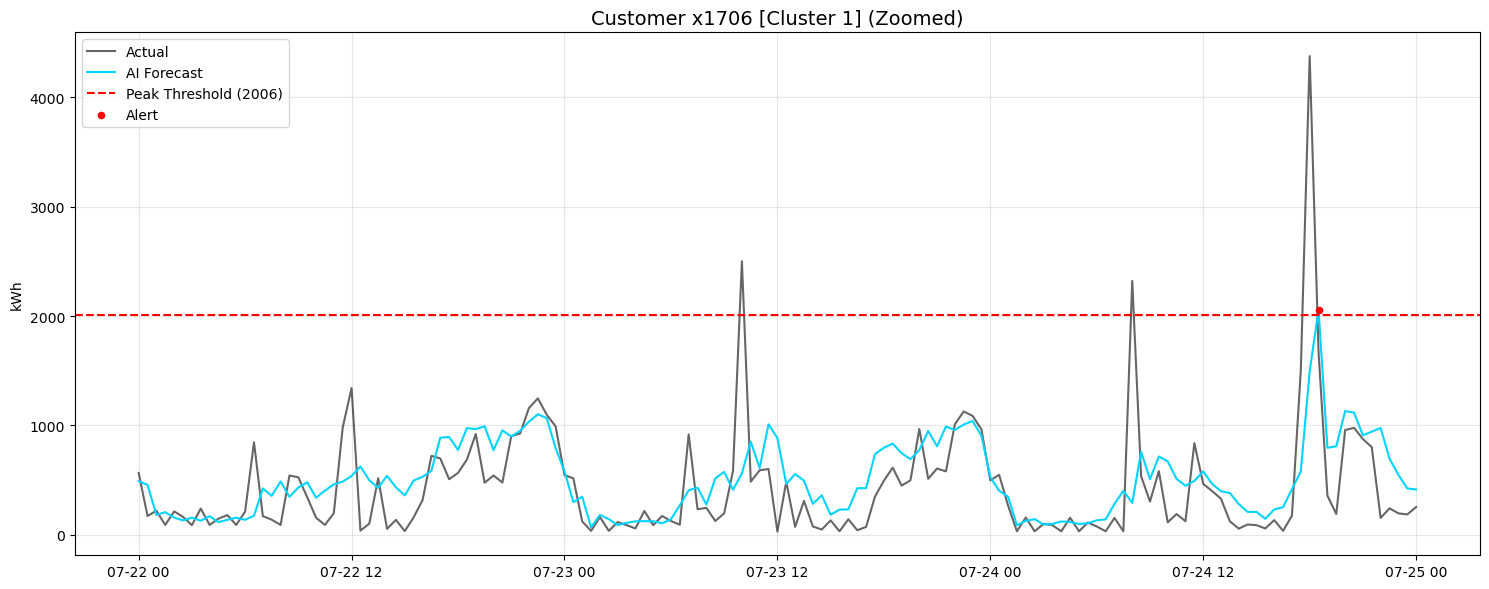

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_customer_forecast(results, customer_id, start_date=None, end_date=None):
    # 1. Filter by Customer ID
    mask = (results['Customer_ID'] == customer_id)
    subset = results.loc[mask].copy()
    
    # 2. Apply Date Filters
    if start_date:
        subset = subset[subset['Time'] >= pd.to_datetime(start_date, dayfirst=True)]
    if end_date:
        subset = subset[subset['Time'] <= pd.to_datetime(end_date, dayfirst=True)]

    subset = subset.sort_values('Time')
    
    if subset.empty:
        print(f"No data found for {customer_id} within range.")
        return

    print(f"Plotting {len(subset)} points.")

    plt.figure(figsize=(15, 6))
    
    # Plot
    plt.plot(subset['Time'], subset['Actual'], label='Actual', color='black', alpha=0.6, linewidth=1.5)
    plt.plot(subset['Time'], subset['Predicted'], label='AI Forecast', color='#00d4ff', linewidth=1.5)
    
    # Threshold (Global 90th percentile)
    threshold = results['Actual'].quantile(0.90)
    plt.axhline(threshold, color='red', linestyle='--', label=f'Peak Threshold ({threshold:.0f})')
    
    # Alerts
    above_threshold = subset[subset['Predicted'] > threshold]
    if not above_threshold.empty:
        plt.scatter(above_threshold['Time'], above_threshold['Predicted'], 
                    color='red', zorder=5, s=20, label='Alert')

    # --- DYNAMIC TITLE WITH CLUSTER INFO ---
    # Try to grab the Cluster ID if it exists
    c_id = subset['Cluster'].iloc[0] if 'Cluster' in subset.columns else 'Unknown'
    
    title_suffix = "(Zoomed)" if (start_date or end_date) else "(Full)"
    plt.title(f"Customer {customer_id} [Cluster {c_id}] {title_suffix}", fontsize=14)
    # ---------------------------------------

    plt.ylabel("kWh")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# EXECUTE
plot_customer_forecast(cluster_forecasts, 'x1706', start_date='22-07-2010', end_date='25-07-2010')

In [13]:
# Check date ranges in the FULL dataset
print("\n--- Full History Available ---")
full_history = df_long.groupby('Customer_ID')['Time'].agg(['min', 'max'])
print(full_history)


--- Full History Available ---
                   min                 max
Customer_ID                               
x1002       2009-08-14 2010-08-14 00:30:00
x1003       2009-08-14 2010-08-14 00:30:00
x1004       2009-08-14 2010-08-14 00:30:00
x1005       2009-08-14 2010-08-14 00:30:00
x1006       2009-08-14 2010-08-14 00:30:00
...                ...                 ...
x1861       2009-08-14 2010-08-14 00:30:00
x1862       2009-08-14 2010-08-14 00:30:00
x1863       2009-08-14 2010-08-14 00:30:00
x1865       2009-08-14 2010-08-14 00:30:00
x1867       2009-08-14 2010-08-14 00:30:00

[500 rows x 2 columns]


###  Tip: When using the plot_customer_forecast function, make sure your start_date falls between the min and max shown in that first table, otherwise the graph will be empty.

# Comparison against baseline

In [14]:
from sklearn.metrics import mean_absolute_error

def compare_against_baseline(df_results):
    print("--- BASELINE COMPARISON ---")
    
    # 1. The "Naive" Forecast: Predict usage will be exactly the same as 24h ago
    # We can approximate this using our Lag_24h feature if available, 
    # or just shift Actual by 48 steps (30 min * 48 = 24h)
    
    # Create the Naive Prediction
    naive_pred = df_results.groupby('Customer_ID')['Actual'].shift(48)
    
    # Filter out the first day (NaNs) so comparison is fair
    valid_indices = naive_pred.dropna().index
    
    y_true = df_results.loc[valid_indices, 'Actual']
    y_naive = naive_pred.loc[valid_indices]
    y_ai = df_results.loc[valid_indices, 'Predicted']
    
    # Calculate Scores
    mae_naive = mean_absolute_error(y_true, y_naive)
    mae_ai = mean_absolute_error(y_true, y_ai)
    
    print(f"Naive Baseline MAE: {mae_naive:.2f}")
    print(f"Your AI Model MAE:  {mae_ai:.2f}")
    
    improvement = ((mae_naive - mae_ai) / mae_naive) * 100
    print(f"Improvement:        {improvement:.2f}%")
    

# Run this on your cluster_forecasts
compare_against_baseline(cluster_forecasts)

--- BASELINE COMPARISON ---
Naive Baseline MAE: 641.17
Your AI Model MAE:  447.00
Improvement:        30.28%


# Metrics

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def comprehensive_evaluation(df_results):
    print("--- COMPREHENSIVE MODEL EVALUATION ---")
    
    y_true = df_results['Actual']
    y_pred = df_results['Predicted']
    
    # 1. MAE (Standard)
    mae = mean_absolute_error(y_true, y_pred)
    
    # 2. RMSE (Punishes Outliers)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 3. sMAPE (Symmetric Mean Absolute Percentage Error)
    # FIXED: Replaces MAPE which was inflated by near-zero actual values
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1)) * 100
    
    # 4. R-Squared (Goodness of Fit)
    r2 = r2_score(y_true, y_pred)
    
    print(f"MAE (Mean Absolute Error):       {mae:.2f} kWh")
    print(f"RMSE (Root Mean Squared Error):  {rmse:.2f} kWh")
    print(f"sMAPE (Symmetric MAPE):          {smape:.2f} %")
    print(f"R² Score (Explained Variance):   {r2:.4f}")
    
    print("-" * 40)
    
    if r2 > 0.7:
        print("✅ Excellent fit")
    elif r2 > 0.5:
        print("✅ Good model, captures trends")
    elif r2 > 0.3:
        print("⚠️ Weak model, highly volatile data")
    else:
        print("❌ Model is not predictive")

# EXECUTE ON YOUR CLUSTER RESULTS
comprehensive_evaluation(cluster_forecasts)


--- COMPREHENSIVE MODEL EVALUATION ---
MAE (Mean Absolute Error):       446.99 kWh
RMSE (Root Mean Squared Error):  872.44 kWh
sMAPE (Symmetric MAPE):          50.52 %
R² Score (Explained Variance):   0.4635
----------------------------------------
⚠️ Weak model, highly volatile data


INTERPRETATION GUIDE:
1. If points are symmetric around the red line: Good (Unbiased).
2. If points curve or fan out: The model struggles with high/low values.


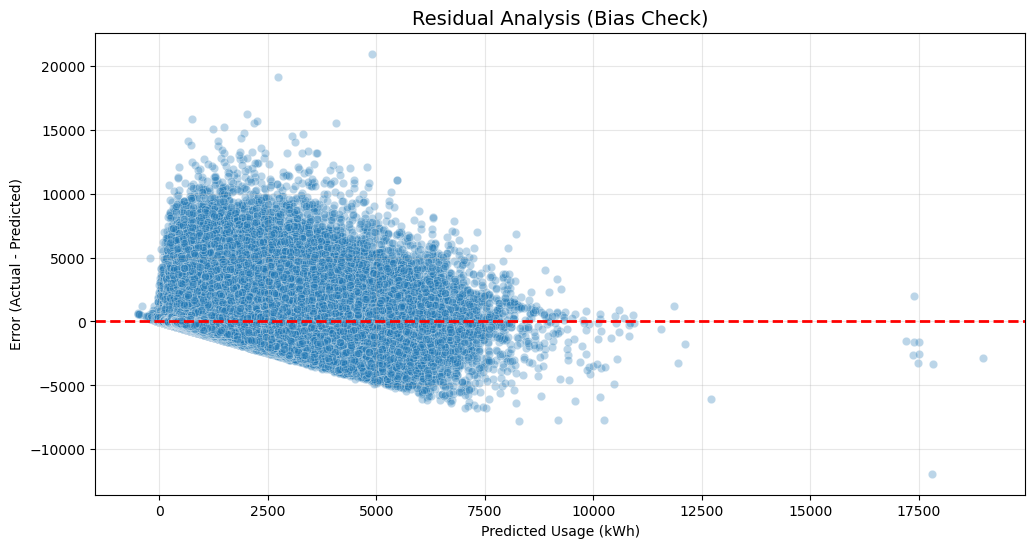

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_residuals(df_results):
    # Calculate Residuals (Error)
    df_results['Residuals'] = df_results['Actual'] - df_results['Predicted']
    
    plt.figure(figsize=(12, 6))
    
    # Scatter plot of Predicted vs Residuals
    sns.scatterplot(x=df_results['Predicted'], y=df_results['Residuals'], alpha=0.3)
    
    # Add a zero line (Perfect prediction)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    
    plt.title("Residual Analysis (Bias Check)", fontsize=14)
    plt.xlabel("Predicted Usage (kWh)")
    plt.ylabel("Error (Actual - Predicted)")
    plt.grid(True, alpha=0.3)
    
    print("INTERPRETATION GUIDE:")
    print("1. If points are symmetric around the red line: Good (Unbiased).")
    print("2. If points curve or fan out: The model struggles with high/low values.")
    
    plt.show()

# EXECUTE
plot_residuals(cluster_forecasts)

# Optimisation: New Features + Optuna Hyperparameter Tuning

In [17]:
# ============================================================
# STEP 1: Enhanced Feature Engineering (adds month + lag_48h)
# ============================================================

import numpy as np

def engineer_features_v2(df_in):
    data = df_in.copy()
    
    # 1. Time Components
    data['hour'] = data['Time'].dt.hour
    data['day_of_week'] = data['Time'].dt.dayofweek
    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    data['month'] = data['Time'].dt.month  # NEW: captures seasonal patterns
    
    # 2. Cyclical Time Encoding
    data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
    
    # 3. Lag Features
    # 48 steps = 24h, 96 steps = 48h, 336 steps = 1 week
    data['lag_24h'] = data.groupby('Customer_ID')['Usage'].shift(48)
    data['lag_48h'] = data.groupby('Customer_ID')['Usage'].shift(96)   # NEW
    data['lag_1week'] = data.groupby('Customer_ID')['Usage'].shift(336)
    
    # 4. Rolling Statistics (transform to stay within customer groups)
    data['rolling_mean_2h'] = data.groupby('Customer_ID')['Usage'].transform(
        lambda x: x.shift(1).rolling(window=4).mean()
    )
    data['rolling_max_24h'] = data.groupby('Customer_ID')['Usage'].transform(
        lambda x: x.shift(1).rolling(window=48).max()
    )
    
    # 5. Velocity
    data['velocity'] = data.groupby('Customer_ID')['Usage'].diff()
    data['velocity_lag1'] = data.groupby('Customer_ID')['velocity'].shift(1)
    
    # Remove NaN rows
    data = data.dropna()
    
    return data

# Execute
df_features_v2 = engineer_features_v2(df_long)
print(f"V2 Features ready. Rows: {len(df_features_v2)}")

V2 Features ready. Rows: 8592000


In [18]:
# ============================================================
# STEP 2: Re-cluster using V2 features (training data only)
# ============================================================

customer_clusters_v2 = cluster_customers(df_features_v2, CUTOFF_DATE)
df_features_v2['Cluster'] = df_features_v2['Customer_ID'].map(customer_clusters_v2)

Generating Customer Profiles for Clustering (training data only)...
Clustering Complete. Found 3 groups.
Cluster
0     71
1    212
2    217
Name: count, dtype: int64


In [19]:
# ============================================================
# STEP 3: Optuna Hyperparameter Tuning
# ============================================================
# Finds the best LightGBM hyperparameters per cluster.
# Run time: ~5-15 minutes depending on data size.

!pip install optuna
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

FEATURES_V2 = ['hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'month',
               'season', 'quarter', 'lag_24h', 'lag_48h', 'lag_1week',
               'rolling_mean_2h', 'rolling_max_24h', 'velocity_lag1']

def optuna_objective(trial, train_X, train_y, val_X, val_y):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        train_X, train_y,
        eval_set=[(val_X, val_y)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    preds = model.predict(val_X)
    return mean_absolute_error(val_y, preds)


def train_tuned_model(data, cutoff_date, n_trials=50):
    df = data.copy()
    
    # Temporal split
    train_mask = df['Time'] < cutoff_date
    
    # Normalize target (training max only)
    train_max = df.loc[train_mask].groupby('Customer_ID')['Usage'].max()
    scaling_factors = df['Customer_ID'].map(train_max)
    df['Target_Norm'] = df['Usage'] / (scaling_factors + 0.0001)
    
    # Prepare features
    df['Customer_ID'] = df['Customer_ID'].astype('category')
    features = FEATURES_V2 + ['Customer_ID']
    
    X = df[features]
    y = df['Target_Norm']
    
    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]
    
    # --- OPTUNA SEARCH ---
    study = optuna.create_study(direction='minimize')
    study.optimize(
        lambda trial: optuna_objective(trial, X_train, y_train, X_test, y_test),
        n_trials=n_trials,
        show_progress_bar=True
    )
    
    best_params = study.best_params
    print(f"   Best params: {best_params}")
    print(f"   Best normalized MAE: {study.best_value:.4f}")
    
    # --- RETRAIN WITH BEST PARAMS ---
    final_model = lgb.LGBMRegressor(
        objective='regression', n_estimators=2000, verbosity=-1,
        n_jobs=-1, random_state=42, **best_params
    )
    final_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    # Inverse transform
    preds_ratio = final_model.predict(X_test)
    test_scaling = scaling_factors[~train_mask]
    preds_real = preds_ratio * test_scaling
    y_test_real = df.loc[~train_mask, 'Usage']
    
    mae = mean_absolute_error(y_test_real, preds_real)
    print(f"   > Tuned Cluster MAE: {mae:.2f}")
    
    results = X_test.copy()
    results['Actual'] = y_test_real.values
    results['Predicted'] = preds_real.values
    results['Time'] = df.loc[~train_mask, 'Time'].values
    
    return final_model, results, best_params

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 24.1 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter 1.0.0 requires nbconvert, which is not installed.
jupyter-server 2.14.1 requires nbconvert>=6.4.4, which is not installed.
tensorflow 2.10.0 requires libclang>=13.0.0, which is not installed.
tensorflow 2.10.0 requires tensorflow-io-gcs-filesystem>=0.23.1, which is not installed.
tensorflow 2.10.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.


In [20]:
# ============================================================
# STEP 4: Run Tuned Training Loop (all clusters)
# ============================================================

print("Starting Optuna-Tuned Clustered Training...")
print("(This may take 5-15 minutes)\n")

all_results_tuned = []
models_tuned = {}
best_params_per_cluster = {}

unique_clusters = sorted(df_features_v2['Cluster'].dropna().unique())

for cluster_id in unique_clusters:
    print(f"\n{'='*50}")
    print(f"--- Tuning Cluster {int(cluster_id)} ---")
    print(f"{'='*50}")
    
    cluster_data = df_features_v2[df_features_v2['Cluster'] == cluster_id].copy()
    cluster_data = cluster_data.drop(columns=['Cluster'])
    
    model, results, best_params = train_tuned_model(cluster_data, CUTOFF_DATE, n_trials=50)
    
    results['Cluster'] = cluster_id
    models_tuned[cluster_id] = model
    best_params_per_cluster[cluster_id] = best_params
    all_results_tuned.append(results)

# Combine results
cluster_forecasts_tuned = pd.concat(all_results_tuned)

final_mae_tuned = mean_absolute_error(cluster_forecasts_tuned['Actual'], cluster_forecasts_tuned['Predicted'])
print(f"\n{'='*50}")
print(f"FINAL TUNED MAE: {final_mae_tuned:.2f}")
print(f"{'='*50}")


Starting Optuna-Tuned Clustered Training...
(This may take 5-15 minutes)


--- Tuning Cluster 0 ---


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1066]	valid_0's l1: 0.0419962
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.0425074
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[739]	valid_0's l1: 0.0421153
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1126]	valid_0's l1: 0.0418688
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's l1: 0.0419872
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[827]	valid_0's l1: 0.0419048
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.0421424
Training until validation scores don't improve for 50 rounds
Did not meet 

  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1982]	valid_0's l1: 0.030012
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1997]	valid_0's l1: 0.0297864
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.0294682
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.0296646
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.029985
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1977]	valid_0's l1: 0.0294572
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1540]	valid_0's l1: 0.0294865
Training until validation scores do

  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1996]	valid_0's l1: 0.0394367
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.0392365
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's l1: 0.0392112
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's l1: 0.0393921
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1998]	valid_0's l1: 0.0392687
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.0397419
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1076]	valid_0's l1: 0.0391172
Training until validation scores 

# Results: Before vs After Optimisation

In [21]:
# ============================================================
# STEP 5: Side-by-Side Comparison
# ============================================================

from sklearn.metrics import mean_squared_error, r2_score

def compare_models(original_results, tuned_results):
    print("==============================================================")
    print("            MODEL COMPARISON: BEFORE vs AFTER")
    print("==============================================================\n")
    
    for label, res in [("ORIGINAL (untuned)", original_results), 
                       ("OPTIMISED (new features + Optuna)", tuned_results)]:
        y_true = res['Actual']
        y_pred = res['Predicted']
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1)) * 100
        
        print(f"--- {label} ---")
        print(f"  MAE:   {mae:.2f} kWh")
        print(f"  RMSE:  {rmse:.2f} kWh")
        print(f"  sMAPE: {smape:.2f} %")
        print(f"  R2:    {r2:.4f}")
        print()
    
    # Improvement summary
    mae_old = mean_absolute_error(original_results['Actual'], original_results['Predicted'])
    mae_new = mean_absolute_error(tuned_results['Actual'], tuned_results['Predicted'])
    improvement = ((mae_old - mae_new) / mae_old) * 100
    
    print(f"MAE Improvement: {improvement:.2f}%")
    if improvement > 0:
        print(f"Optimised model is better by {mae_old - mae_new:.2f} kWh")
    else:
        print(f"Original model was better (consider reverting)")

    # Naive baseline comparison for tuned model
    print("\n--- Naive Baseline Check (Tuned Model) ---")
    naive_pred = tuned_results.groupby('Customer_ID')['Actual'].shift(48)
    valid = naive_pred.dropna().index
    mae_naive = mean_absolute_error(tuned_results.loc[valid, 'Actual'], naive_pred[valid])
    mae_ai = mean_absolute_error(tuned_results.loc[valid, 'Actual'], tuned_results.loc[valid, 'Predicted'])
    print(f"  Naive MAE: {mae_naive:.2f}")
    print(f"  Tuned MAE: {mae_ai:.2f}")
    print(f"  vs Baseline Improvement: {((mae_naive - mae_ai) / mae_naive) * 100:.2f}%")

compare_models(cluster_forecasts, cluster_forecasts_tuned)

            MODEL COMPARISON: BEFORE vs AFTER

--- ORIGINAL (untuned) ---
  MAE:   446.99 kWh
  RMSE:  872.44 kWh
  sMAPE: 50.52 %
  R2:    0.4635

--- OPTIMISED (new features + Optuna) ---
  MAE:   438.04 kWh
  RMSE:  864.88 kWh
  sMAPE: 49.43 %
  R2:    0.4727

MAE Improvement: 2.00%
Optimised model is better by 8.95 kWh

--- Naive Baseline Check (Tuned Model) ---
  Naive MAE: 641.17
  Tuned MAE: 438.05
  vs Baseline Improvement: 31.68%


In [22]:
# ============================================================
# STEP 6: Per-Cluster Performance Breakdown
# ============================================================

print("Per-Cluster MAE Comparison:\n")
print(f"{'Cluster':<10} {'Original MAE':<18} {'Tuned MAE':<18} {'Change':<12}")
print("-" * 58)

for c_id in sorted(cluster_forecasts['Cluster'].unique()):
    orig = cluster_forecasts[cluster_forecasts['Cluster'] == c_id]
    tuned = cluster_forecasts_tuned[cluster_forecasts_tuned['Cluster'] == c_id]
    
    if len(orig) > 0 and len(tuned) > 0:
        mae_orig = mean_absolute_error(orig['Actual'], orig['Predicted'])
        mae_tuned = mean_absolute_error(tuned['Actual'], tuned['Predicted'])
        change = ((mae_orig - mae_tuned) / mae_orig) * 100
        symbol = "↓" if change > 0 else "↑"
        print(f"{int(c_id):<10} {mae_orig:<18.2f} {mae_tuned:<18.2f} {symbol} {abs(change):.1f}%")

Per-Cluster MAE Comparison:

Cluster    Original MAE       Tuned MAE          Change      
----------------------------------------------------------
0          768.97             754.78             ↓ 1.8%
1          273.53             267.95             ↓ 2.0%
2          511.10             500.57             ↓ 2.1%


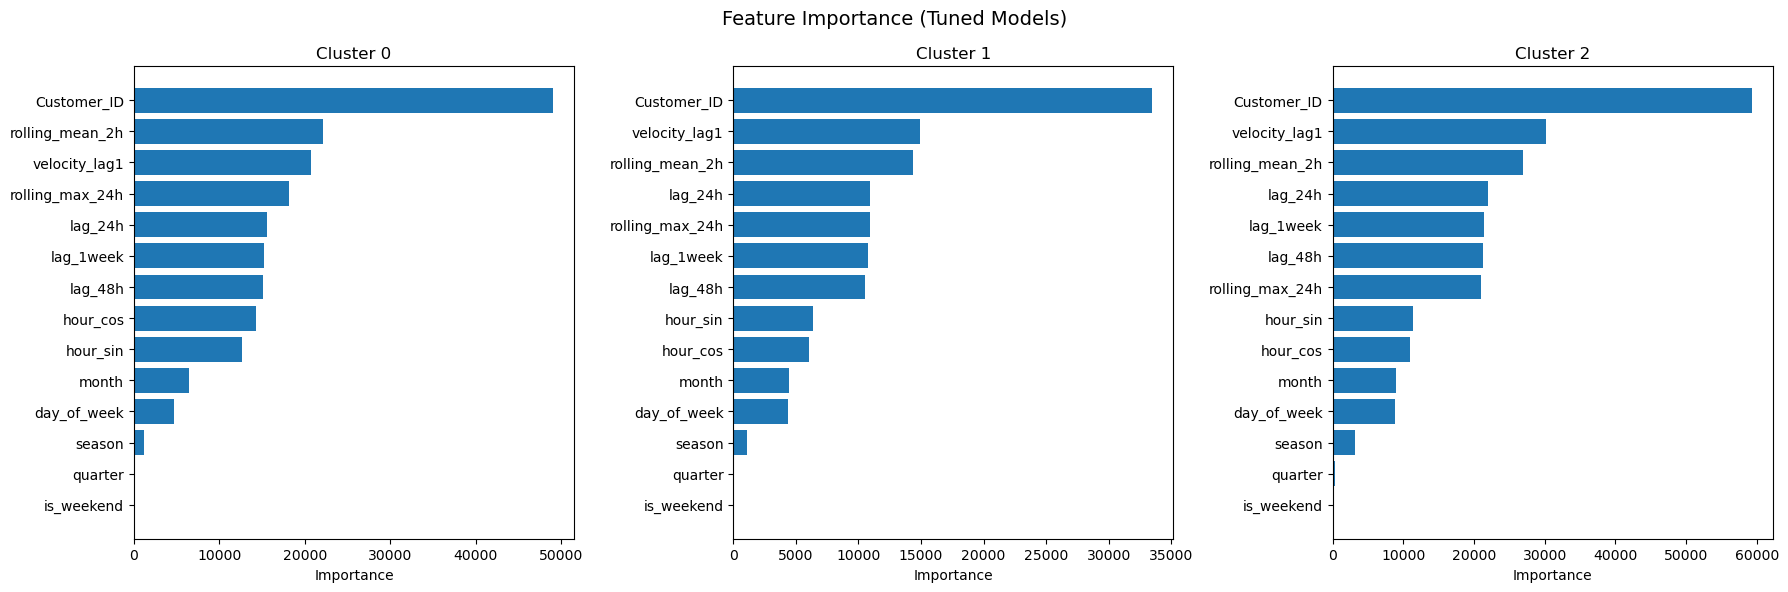

In [23]:
# ============================================================
# STEP 7: Feature Importance (Tuned Model)
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(models_tuned), figsize=(6 * len(models_tuned), 6))
if len(models_tuned) == 1:
    axes = [axes]

for idx, (cluster_id, model) in enumerate(models_tuned.items()):
    importance = model.feature_importances_
    feature_names = FEATURES_V2 + ['Customer_ID']
    
    sorted_idx = np.argsort(importance)
    
    axes[idx].barh(range(len(sorted_idx)), importance[sorted_idx])
    axes[idx].set_yticks(range(len(sorted_idx)))
    axes[idx].set_yticklabels([feature_names[i] for i in sorted_idx])
    axes[idx].set_title(f"Cluster {int(cluster_id)}")
    axes[idx].set_xlabel("Importance")

plt.suptitle("Feature Importance (Tuned Models)", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Peak Detection Accuracy (Precision, Recall, F1)
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def peak_detection_metrics(df_results, quantile=0.90):
    threshold = df_results['Actual'].quantile(quantile)
    
    # Binary labels: 1 = peak, 0 = normal
    actual_peaks = (df_results['Actual'] > threshold).astype(int)
    predicted_peaks = (df_results['Predicted'] > threshold).astype(int)
    
    precision = precision_score(actual_peaks, predicted_peaks)
    recall = recall_score(actual_peaks, predicted_peaks)
    f1 = f1_score(actual_peaks, predicted_peaks)
    cm = confusion_matrix(actual_peaks, predicted_peaks)
    
    print(f"Peak Threshold (90th percentile): {threshold:.0f} kWh")
    print(f"Total actual peaks:    {actual_peaks.sum()}")
    print(f"Total predicted peaks: {predicted_peaks.sum()}")
    print()
    print(f"Precision: {precision:.4f}  — Of all predicted peaks, {precision*100:.1f}% were real")
    print(f"Recall:    {recall:.4f}  — Of all actual peaks, {recall*100:.1f}% were caught")
    print(f"F1 Score:  {f1:.4f}")
    print()
    print("Confusion Matrix:")
    print(f"  TN={cm[0][0]:>8,}   FP={cm[0][1]:>8,}")
    print(f"  FN={cm[1][0]:>8,}   TP={cm[1][1]:>8,}")
    print()
    
    # Missed peaks vs false alarms
    missed = cm[1][0]
    false_alarms = cm[0][1]
    print(f"Missed peaks (dangerous): {missed:,}")
    print(f"False alarms (wasteful):  {false_alarms:,}")

print("--- ORIGINAL FIXED MODEL ---")
peak_detection_metrics(cluster_forecasts)
print()
print("--- OPTIMISED MODEL ---")
peak_detection_metrics(cluster_forecasts_tuned)

--- ORIGINAL FIXED MODEL ---
Peak Threshold (90th percentile): 2006 kWh
Total actual peaks:    146440
Total predicted peaks: 129536

Precision: 0.5674  — Of all predicted peaks, 56.7% were real
Recall:    0.5019  — Of all actual peaks, 50.2% were caught
F1 Score:  0.5326

Confusion Matrix:
  TN=1,262,521   FP=  56,039
  FN=  72,943   TP=  73,497

Missed peaks (dangerous): 72,943
False alarms (wasteful):  56,039

--- OPTIMISED MODEL ---
Peak Threshold (90th percentile): 2006 kWh
Total actual peaks:    146440
Total predicted peaks: 126163

Precision: 0.5811  — Of all predicted peaks, 58.1% were real
Recall:    0.5007  — Of all actual peaks, 50.1% were caught
F1 Score:  0.5379

Confusion Matrix:
  TN=1,265,715   FP=  52,845
  FN=  73,122   TP=  73,318

Missed peaks (dangerous): 73,122
False alarms (wasteful):  52,845


--- Fixed Model: Per-Customer MAE Summary ---
  Median customer MAE: 426.22 kWh
  Mean customer MAE:   446.99 kWh
  Best customer:       8.29 kWh (x1112)
  Worst customer:      1128.60 kWh (x1217)
  Customers < 200 MAE: 65 / 500
  Customers < 500 MAE: 308 / 500

--- Optimised Model: Per-Customer MAE Summary ---
  Median customer MAE: 420.13 kWh
  Mean customer MAE:   438.04 kWh
  Best customer:       9.39 kWh (x1112)
  Worst customer:      1129.81 kWh (x1217)
  Customers < 200 MAE: 73 / 500
  Customers < 500 MAE: 316 / 500



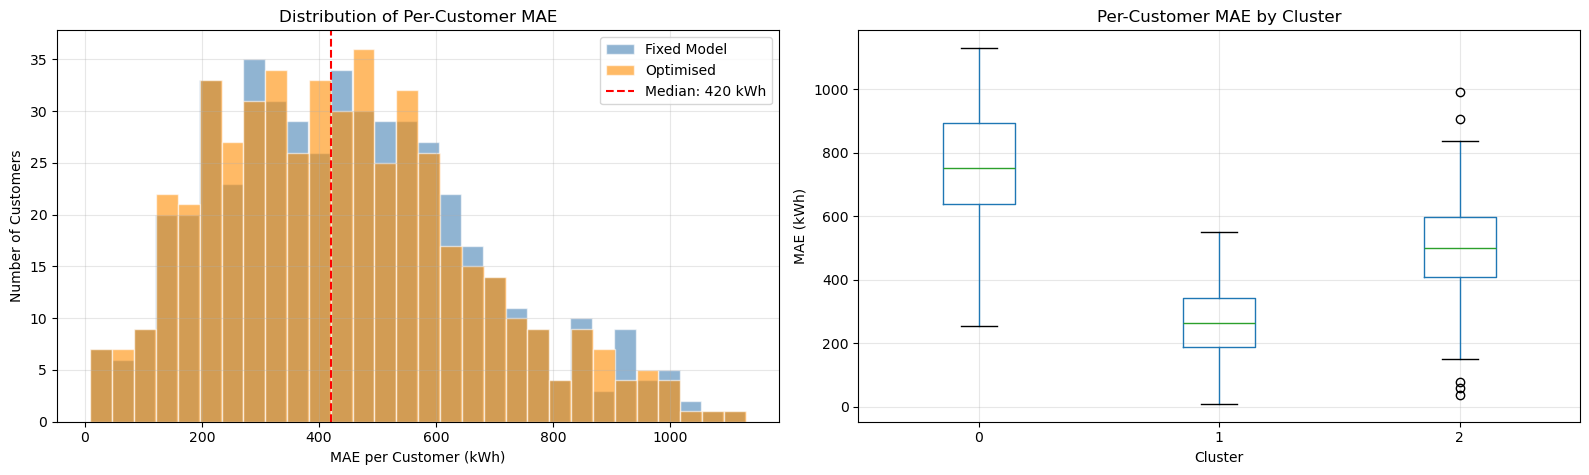

In [25]:
# ============================================================
# Per-Customer MAE Distribution
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def customer_mae_distribution(df_results, label="Model"):
    # Calculate MAE per customer
    customer_maes = df_results.groupby('Customer_ID').apply(
        lambda g: np.mean(np.abs(g['Actual'] - g['Predicted']))
    ).sort_values()
    
    print(f"--- {label}: Per-Customer MAE Summary ---")
    print(f"  Median customer MAE: {customer_maes.median():.2f} kWh")
    print(f"  Mean customer MAE:   {customer_maes.mean():.2f} kWh")
    print(f"  Best customer:       {customer_maes.iloc[0]:.2f} kWh ({customer_maes.index[0]})")
    print(f"  Worst customer:      {customer_maes.iloc[-1]:.2f} kWh ({customer_maes.index[-1]})")
    print(f"  Customers < 200 MAE: {(customer_maes < 200).sum()} / {len(customer_maes)}")
    print(f"  Customers < 500 MAE: {(customer_maes < 500).sum()} / {len(customer_maes)}")
    print()
    
    return customer_maes

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
maes_orig = customer_mae_distribution(cluster_forecasts, "Fixed Model")
maes_tuned = customer_mae_distribution(cluster_forecasts_tuned, "Optimised Model")

axes[0].hist(maes_orig, bins=30, alpha=0.6, label='Fixed Model', color='steelblue', edgecolor='white')
axes[0].hist(maes_tuned, bins=30, alpha=0.6, label='Optimised', color='darkorange', edgecolor='white')
axes[0].axvline(maes_tuned.median(), color='red', linestyle='--', label=f'Median: {maes_tuned.median():.0f} kWh')
axes[0].set_xlabel('MAE per Customer (kWh)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution of Per-Customer MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot by cluster
cluster_maes = cluster_forecasts_tuned.groupby(['Cluster', 'Customer_ID']).apply(
    lambda g: np.mean(np.abs(g['Actual'] - g['Predicted']))
).reset_index(name='MAE')

cluster_maes.boxplot(column='MAE', by='Cluster', ax=axes[1])
axes[1].set_title('Per-Customer MAE by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('MAE (kWh)')
axes[1].get_figure().suptitle('')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Per-Cluster Detailed Metrics (R², sMAPE, MAE)
# ============================================================
from sklearn.metrics import r2_score

def per_cluster_detailed(df_results, label="Model"):
    print(f"--- {label}: Per-Cluster Detailed Metrics ---\n")
    print(f"{'Cluster':<10} {'Customers':<12} {'MAE':<12} {'sMAPE':<12} {'R²':<12}")
    print("-" * 58)
    
    for c_id in sorted(df_results['Cluster'].unique()):
        subset = df_results[df_results['Cluster'] == c_id]
        y_true = subset['Actual']
        y_pred = subset['Predicted']
        
        n_customers = subset['Customer_ID'].nunique()
        mae = np.mean(np.abs(y_true - y_pred))
        smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1)) * 100
        r2 = r2_score(y_true, y_pred)
        
        print(f"{int(c_id):<10} {n_customers:<12} {mae:<12.2f} {smape:<12.2f} {r2:<12.4f}")
    print()

per_cluster_detailed(cluster_forecasts, "Fixed Model")
per_cluster_detailed(cluster_forecasts_tuned, "Optimised Model")

--- Fixed Model: Per-Cluster Detailed Metrics ---

Cluster    Customers    MAE          sMAPE        R²          
----------------------------------------------------------
0          71           768.97       50.89        0.4390      
1          212          273.53       52.15        0.3774      
2          217          511.10       48.81        0.4136      

--- Optimised Model: Per-Cluster Detailed Metrics ---

Cluster    Customers    MAE          sMAPE        R²          
----------------------------------------------------------
0          71           754.78       49.78        0.4477      
1          212          267.95       50.97        0.3889      
2          217          500.57       47.81        0.4240      

